# Text Preprocessing and Feature Engineering

In [ ]:
import pandas as pd
import numpy as np
import re
import pickle
from pathlib import Path

from tqdm import tqdm
import warnings # just to hide the warnings for now
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
# from sklearn.ensemble import RandomForestClassifier # might use later

## Load Training and Test Data

In [ ]:
TRAIN_PATH = 'train_cleaned.csv' # this is the cleaned file from the EDA notebook
TEST_PATH = 'test.csv'

# where i'll save the features
FEATURES_DIR = Path('features')
FEATURES_DIR.mkdir(exist_ok=True)

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

Train shape: (75000, 7)
Test shape: (75000, 3)


## Text Cleaning

In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text) # get rid of html tags
    text = re.sub(r'\s+', ' ', text) # whitespace
    return text.strip()


# checking the function on one example
sample_text = df_train['catalog_content'].iloc[0]
cleaned = clean_text(sample_text)

print("--- BEFORE ---")
print(sample_text[:200])
print("\n--- AFTER ---")
print(cleaned[:200])

--- BEFORE ---
Item Name: La Victoria Green Taco Sauce Mild, 12 Ounce (Pack of 6)
Value: 72.0
Unit: Fl Oz


--- AFTER ---
item name: la victoria green taco sauce mild, 12 ounce (pack of 6) value: 72.0 unit: fl oz


In [ ]:
from tqdm import tqdm
tqdm.pandas()

print("Cleaning train data")
df_train['cleaned_text'] = df_train['catalog_content'].progress_apply(clean_text)

print("Cleaning test data")
df_test['cleaned_text'] = df_test['catalog_content'].progress_apply(clean_text)

print("finished cleaning")

Cleaning train data


100%|██████████| 75000/75000 [00:07<00:00, 10052.67it/s]


Cleaning test data


100%|██████████| 75000/75000 [00:06<00:00, 11858.21it/s]

finished cleaning


## Feature Extraction: Pack Quantity

Extract item pack quantity as it strongly correlates with price.

In [ ]:
# try to get the pack size from the catalog content
def extract_pack_quantity(text):
    if pd.isna(text):
        return 1 # default to 1 item

    # giant regex to find all the different ways people write "pack of X"
    # pack of N, N-pack, N count, set of N, etc
    match = re.search(
        r'(?:pack of|set of)\s*(\d+)|(\d+)\s*(?:pack|piece|count|unit)|(\d+)-pack',
        str(text).lower()
    )

    if match:
        # find which capture group actually caught a number
        quantity_str = next((g for g in match.groups() if g is not None), None)
        if quantity_str:
            qty = int(quantity_str)
            # cap at 50, saw some weird stuff like "2020" being picked up as a year
            return min(qty, 50)

    return 1 # if nothing found, it's probably a single item


print("Extracting pack quantity feature...")
df_train['pack_quantity'] = df_train['catalog_content'].progress_apply(extract_pack_quantity)
df_test['pack_quantity'] = df_test['catalog_content'].progress_apply(extract_pack_quantity)

print("Done.")

print("\nTrain pack counts:")
print(df_train['pack_quantity'].value_counts().head())

print("\nTest pack counts:")
print(df_test['pack_quantity'].value_counts().head())

Extracting pack quantity feature...


100%|██████████| 75000/75000 [00:04<00:00, 17682.23it/s]

Done.

Train pack counts:
pack_quantity
0     30120
6      6001
12     5327
2      5307
3      4328
Name: count, dtype: int64

Test pack counts:
pack_quantity
0     30283
6      6014
12     5429
2      5363
3      4159
Name: count, dtype: int64


## Feature Extraction

In [ ]:
# some basic feature engineering from the text itself
def extract_text_stats(text):
    if pd.isna(text) or text == "":
        return {
            'char_count': 0,
            'word_count': 0,
            'avg_word_len': 0,
            'digit_ratio': 0, # as a ratio of total chars
            'upper_ratio': 0,
        }

    words = text.split()
    char_len = len(text)

    # avoid division by zero
    if char_len == 0:
        return {'char_count': 0,'word_count': 0, 'avg_word_len': 0, 'digit_ratio': 0, 'upper_ratio': 0}

    return {
        'char_count': char_len,
        'word_count': len(words),
        'avg_word_len': sum(len(w) for w in words) /len(words) if words else 0,
        'digit_ratio': sum(c.isdigit() for c in text)/ char_len,
        'upper_ratio': sum(c.isupper() for c in text) / char_len,
    }


print("Getting text stats...")
train_text_features = pd.DataFrame(df_train['cleaned_text'].progress_apply(extract_text_stats).tolist(), index=df_train.index)
test_text_features = pd.DataFrame(df_test['cleaned_text'].progress_apply(extract_text_stats).tolist(), index=df_test.index)
df_train = df_train.join(train_text_features.add_prefix('text_'))
df_test = df_test.join(test_text_features.add_prefix('text_'))
print("Text features extracted.")
print(df_train[['text_char_count', 'text_word_count', 'text_avg_word_len', 'text_digit_ratio']].head())

Getting text stats...


100%|██████████| 75000/75000 [00:13<00:00, 5520.92it/s]


Text features extracted.
   text_char_count  text_word_count  text_avg_word_len  text_digit_ratio
0               90               18           4.055556          0.066667
1              510               80           5.387500          0.033333
2              327               59           4.559322          0.036697
3             1317              211           5.246445          0.012908
4              154               28           4.535714          0.084416


## TF-IDF Feature Extraction

Create TF-IDF vectors to get important words in product descriptions.
We'll use dimensionality reduction to keep features short.

In [ ]:
# We need to fit the TFIDF on all the text data (train + test)
# so it builds a single consistent vocabulary
all_texts = pd.concat([df_train['cleaned_text'], df_test['cleaned_text']]).reset_index(drop=True)

print(f"Combined text data shape: {all_texts.shape}")

# setup the vectorizer. Capping features to 5k to keep it manageable
# also using ngrams (1,2) to catch common word pairs
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    min_df=5,
    max_df=0.8,
    sublinear_tf=True
)


print("Fitting vectorizer... this will take a bit")
tfidf_features = vectorizer.fit_transform(all_texts)


print("Done.")
print(f"Shape of TF-IDF matrix: {tfidf_features.shape}")
# print(f"Vocab size: {len(vectorizer.vocabulary_)}") # just to check

Combined text data shape: (150000,)
Fitting vectorizer... this will take a bit
Done.
Shape of TF-IDF matrix: (150000, 5000)


In [ ]:
# 5000 features is still a bit much, lets reduce it down with SVD
# basically Latent Semantic Analysis
n_comps = 200

svd = TruncatedSVD(n_components=n_comps, random_state=42)

print(f"Running SVD to get {n_comps} features...")
lsa_features = svd.fit_transform(tfidf_features)

print(f"SVD features shape: {lsa_features.shape}")
# check how much information we're keeping
print(f"Total variance explained: {svd.explained_variance_ratio_.sum():.3f}")


# now we need to split this back into train and test sets
train_size = len(df_train)
svd_train = lsa_features[:train_size]
svd_test = lsa_features[train_size:]

print(f"\nTrain SVD shape: {svd_train.shape}")
print(f"Test SVD shape: {svd_test.shape}")

Running SVD to get 200 features...
SVD features shape: (150000, 200)
Total variance explained: 0.368

Train SVD shape: (75000, 200)
Test SVD shape: (75000, 200)


## Save TF-IDF Features

Save the TF-IDF features and fitted transformers for later use.

In [ ]:
print("Saving features to disk...")
np.save(FEATURES_DIR / 'svd_train_features.npy', svd_train)
np.save(FEATURES_DIR / 'svd_test_features.npy', svd_test)
with open(FEATURES_DIR / 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
with open(FEATURES_DIR / 'svd_transformer.pkl', 'wb') as f:
    pickle.dump(svd, f)
print(f"All good. Files are in the '{FEATURES_DIR}' folder.")

Saving features to disk...
All good. Files are in the 'features' folder.


## Extract Price Range Features (Training Only)

Create log-transformed price for better model learning.

Clipping prices outside of ($1.08, $183.70)
This affected 743 rows (0.99%)

Visualizing price distributions...


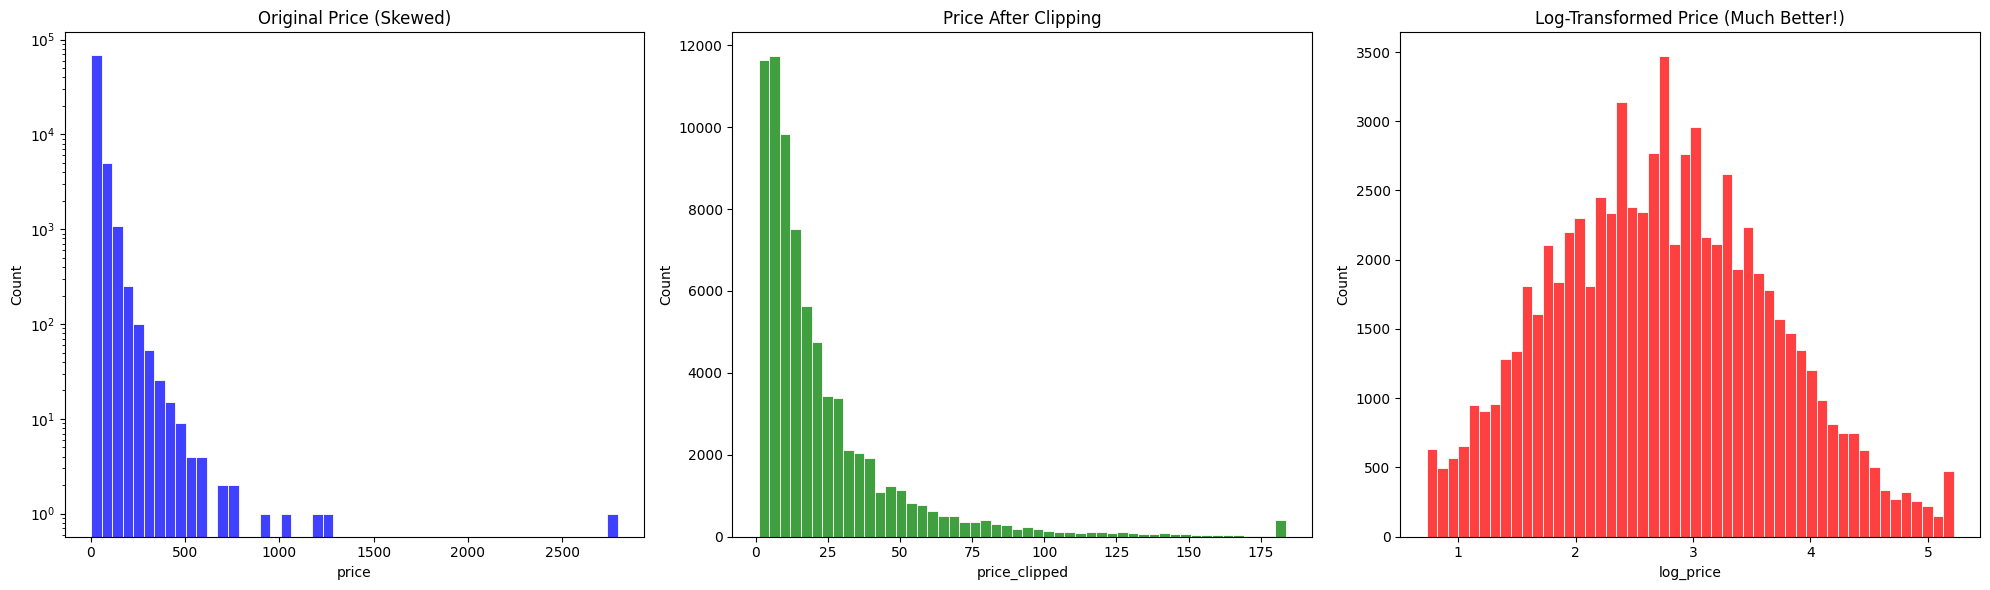

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns # for better plots

# The price is super skewed, so let's clip the extreme outliers.
# Using the 0.5% and 99.5% percentiles should work well.
lower_bound = df_train['price'].quantile(0.005)
upper_bound = df_train['price'].quantile(0.995)

print(f"Clipping prices outside of (${lower_bound:.2f}, ${upper_bound:.2f})")

df_train['price_clipped'] = df_train['price'].clip(lower_bound, upper_bound)
rows_affected = (df_train['price'] != df_train['price_clipped']).sum()
print(f"This affected {rows_affected} rows ({rows_affected/len(df_train):.2%})")
df_train['log_price'] = np.log1p(df_train['price_clipped'])

# important: save the bounds so we can use them on the test set later
price_bounds = {
    'lower_bound': lower_bound,
    'upper_bound': upper_bound
}
with open(FEATURES_DIR / 'price_clip_thresholds.pkl', 'wb') as f:
    pickle.dump(price_bounds, f)

print("\nVisualizing price distributions...")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_style("whitegrid")

# 1. Original
sns.histplot(df_train['price'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('Original Price (Skewed)')
axes[0].set_yscale('log') # use log scale to even see the distribution

# 2. Clipped
sns.histplot(df_train['price_clipped'], bins=50, ax=axes[1], color='green')
axes[1].set_title('Price After Clipping')

# 3. Log-transformed
sns.histplot(df_train['log_price'], bins=50, ax=axes[2], color='red')
axes[2].set_title('Log-Transformed Price (Much Better!)')

plt.tight_layout()
plt.show()

## Compile Basic Features

Create feature matrices with all engineered features (excluding TF-IDF for now).

In [ ]:
basic_feature_cols = [
    'pack_quantity',
    'text_char_count',
    'text_word_count',
    'text_avg_word_len',
    'text_digit_ratio',
    'text_upper_ratio',
]
X_basic_train = df_train[basic_feature_cols].values
X_basic_test = df_test[basic_feature_cols].values

# This is the target we're trying to predict (the log version)
y_train_log = df_train['log_price'].values

print("Train basic features:", X_basic_train.shape)
print("Test basic features:", X_basic_test.shape)
print("Target:", y_train_log.shape)

# save these arrays so we can just load them in the modeling notebook
np.save(FEATURES_DIR / 'X_basic_train.npy', X_basic_train)
np.save(FEATURES_DIR / 'X_basic_test.npy', X_basic_test)
np.save(FEATURES_DIR / 'y_train_log.npy', y_train_log)

# also saving the original price, maybe for calculating final metrics
np.save(FEATURES_DIR / 'y_train_original.npy', df_train['price'].values)

print("\nDone saving the basic stuff.")

Train basic features: (75000, 6)
Test basic features: (75000, 6)
Target: (75000,)

Done saving the basic stuff.


## Save Processed DataFrames

Save the processed dataframes with all metadata for reference.

In [ ]:
train_cols = ['sample_id', 'cleaned_text', 'pack_quantity', 'price', 'price_clipped', 'log_price'] + \
             [col for col in df_train.columns if col.startswith('text_')]

test_cols = ['sample_id', 'cleaned_text', 'pack_quantity'] + \
            [col for col in df_test.columns if col.startswith('text_')]

df_train[train_cols].to_csv('train_processed.csv', index=False)
df_test[test_cols].to_csv('test_processed.csv', index=False)

print("Processed dataframes saved!")
print(f"\nTrain columns saved: {len(train_cols)}")
print(f"Test columns saved: {len(test_cols)}")

Processed dataframes saved!

Train columns saved: 12
Test columns saved: 8


## Feature Summary

Overview of all extracted features.

In [20]:
print(f"1. We have {len(basic_feature_cols)} basic numeric features:")
for feat in basic_feature_cols:
    print(f"   -> {feat}")

# using the variable names from the previous cells...
print(f"\n2. And {svd_train.shape[1]} features from the SVD on top of TF-IDF.")
print(f"   -> Squeezed down from a vocab of {len(vectorizer.vocabulary_)} words/phrases.")
print(f"   -> These components cover about {svd.explained_variance_ratio_.sum():.1%} of the text's variance.")


total_features = len(basic_feature_cols) + svd_train.shape[1]
print(f"\nSo that's {total_features} total features per product for now.")

print("\nAll the generated files are here:")
for file_path in sorted(FEATURES_DIR.glob('*')):
    # get file size in MB
    size_mb = file_path.stat().st_size / (1024*1024)
    print(f"   - {file_path.name} ({size_mb:.2f} MB)")

1. We have 6 basic numeric features:
   -> pack_quantity
   -> text_char_count
   -> text_word_count
   -> text_avg_word_len
   -> text_digit_ratio
   -> text_upper_ratio

2. And 200 features from the SVD on top of TF-IDF.
   -> Squeezed down from a vocab of 5000 words/phrases.
   -> These components cover about 36.8% of the text's variance.

So that's 206 total features per product for now.

All the generated files are here:
   - X_basic_test.npy (3.43 MB)
   - X_basic_train.npy (3.43 MB)
   - price_clip_thresholds.pkl (0.00 MB)
   - svd_test_features.npy (114.44 MB)
   - svd_train_features.npy (114.44 MB)
   - svd_transformer.pkl (7.63 MB)
   - tfidf_vectorizer.pkl (0.18 MB)
   - y_train_log.npy (0.57 MB)
   - y_train_original.npy (0.57 MB)
